In [4]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.datasets as datasets
from torch.utils.data import DataLoader, TensorDataset

from sklearn.decomposition import PCA

In [5]:
def get_data():    
    mnist_train = datasets.MNIST(root="./data", train=True, download=True)
    mnist_test = datasets.MNIST(root="./data", train=False, download=True)

    # We don't need labels for autoencoders, so we will just use the images as both inputs and targets
    X_train = mnist_train.data.float() / 255.0
    y_train = mnist_train.targets.long()
    X_test = mnist_test.data.float() / 255.0
    y_test = mnist_test.targets.long()

    X = torch.cat([X_train, X_test], dim=0)
    y = torch.cat([y_train, y_test], dim=0)

    return X, y

In [ ]:
x = torch.randn(10, 50) # a single random image (flattened)
W1 = nn.Parameter(torch.randn(128, 50))
print(W1.shape, W1.t().shape) # transpose of W1
print(W1) # it has requires_grad=True by default, so it will be updated during training
y = x @ W1.t() # this is the same as torch.matmul(x, W1.t())
print(y.shape)

torch.Size([128, 50]) torch.Size([50, 128])
Parameter containing:
tensor([[ 0.1063, -0.3777, -0.0182,  ..., -0.0493,  1.3926,  0.2288],
        [ 0.6422,  1.2570,  1.6560,  ...,  0.8203, -0.1799, -1.3225],
        [-0.4823, -0.5465,  0.9499,  ...,  1.2895, -0.6238,  0.3183],
        ...,
        [ 0.2197,  0.3558, -1.3215,  ..., -0.6749, -1.6421, -0.2855],
        [ 0.3102, -0.4330, -0.5309,  ...,  1.1641,  0.2677, -1.6255],
        [-0.7337,  0.2484, -0.8388,  ..., -1.5147, -0.5755,  0.3649]],
       requires_grad=True)
torch.Size([10, 128])
tensor([[  6.4919,   9.0327,   0.6850,  ...,   1.2173,   1.6503,  -9.6519],
        [ 11.6637,  -0.4085,  -1.5704,  ...,   8.3921,  -4.4419,  -1.3860],
        [ -9.3281, -12.1792,   2.1818,  ...,   5.1123,  -0.5652,  -1.8033],
        ...,
        [  2.1882,  -0.5778, -11.5722,  ...,  -2.6345, -12.3791,   5.2180],
        [ -2.3659,  -3.8550,  -0.4981,  ...,  -4.8690,   4.7467,  12.6214],
        [ -6.7097,   9.2208,  -0.9716,  ...,  -2.6665,   3

In [ ]:
print(y)
F.linear(x, W1) # this is the same as x @ W1.t() + bias, but we don't have a bias here, so it's just x @ W1.t()

tensor([[  6.4919,   9.0327,   0.6850,  ...,   1.2173,   1.6503,  -9.6519],
        [ 11.6637,  -0.4085,  -1.5704,  ...,   8.3921,  -4.4419,  -1.3860],
        [ -9.3281, -12.1792,   2.1818,  ...,   5.1123,  -0.5652,  -1.8033],
        ...,
        [  2.1882,  -0.5778, -11.5722,  ...,  -2.6345, -12.3791,   5.2180],
        [ -2.3659,  -3.8550,  -0.4981,  ...,  -4.8690,   4.7467,  12.6214],
        [ -6.7097,   9.2208,  -0.9716,  ...,  -2.6665,   3.2829,   8.8715]],
       grad_fn=<MmBackward0>)

In [ ]:
# nn.Linear is a convenient wrapper that creates both the weight and bias parameters for us, and also defines the forward pass
W2 = nn.Linear(128, 50) 
print(W2) 
print(W2.weight.shape, W2.bias.shape)
print(W1.shape, W2.weight.shape) # W2 shape is transposed compared to W1, because nn.Linear expects input features in the last dimension

Linear(in_features=128, out_features=50, bias=True)
torch.Size([50, 128]) torch.Size([50])
torch.Size([128, 50]) torch.Size([50, 128])


In [11]:
class MNIST_Autoencoder(nn.Module):
    def __init__(self, encoding_dim, bottleneck_dim):
        # we can remove the encoding and decoding layers, and just use a single parameter for the bottleneck transformation
        super().__init__()
        self.fc1 = nn.Linear(28*28, encoding_dim) # first layer
        #self.fc2 = nn.Linear(encoding_dim, bottleneck_dim) # encoder layer (bottleneck)

        # _______________________________________________________________________________________
        # Initialize the tied weight parameter using Xavier/Glorot initialization
        self.param = nn.Parameter(torch.empty(bottleneck_dim, encoding_dim))
        nn.init.xavier_uniform_(self.param) 
        # Optional: Add biases if you want the same expressive power as nn.Linear
        self.bias_enc = nn.Parameter(torch.zeros(bottleneck_dim))
        self.bias_dec = nn.Parameter(torch.zeros(encoding_dim))
        # _______________________________________________________________________________________

        #self.fc3 = nn.Linear(bottleneck_dim, encoding_dim) # decoder layer (same size as encoder)  
        self.fc4 = nn.Linear(encoding_dim, 28*28)  # output layer (same size as input)

    def forward(self, x):
        x = torch.flatten(x, start_dim=1) # flatten the image, keep the batch dimension
        x = F.relu(self.fc1(x))
        x = F.relu(F.linear(x, self.param, self.bias_enc)) # use the parameter as a linear transformation
        x = F.relu(F.linear(x, self.param.t(), self.bias_dec)) # same for decoding layer but transposed
        x = torch.sigmoid(self.fc4(x)) # we use sigmoid to get outputs between 0 and 1, since the input images are normalized to [0, 1]
        return x 
    
def train_autoencoder(model, X, optimizer, loss_fn, epochs):
    
    losses = np.zeros(epochs)

    for epoch in range(epochs):
        model.train()

        # select a random batch of images
        randomidx = np.random.choice(X.shape[0], size=32, replace=False) # random minibatch of 32 images
        X_batch = X[randomidx]

        output = model(X_batch)
        loss = loss_fn(output, X_batch.flatten(start_dim=1)) # we use the same images as both inputs and targets

        # backpropagation and optimization step
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        # losses in this epoch
        losses[epoch] = loss.item()

    return losses

In [12]:
learning_rate = 1e-3
epochs = 10000 # we set a lot of epochs since we are using small minibatches inside the training loop, so it is not so expensive in reality

model = MNIST_Autoencoder(encoding_dim=128, bottleneck_dim=50)
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
loss_fn = nn.MSELoss()

X, y = get_data()
losses = train_autoencoder(model, X, optimizer, loss_fn, epochs)

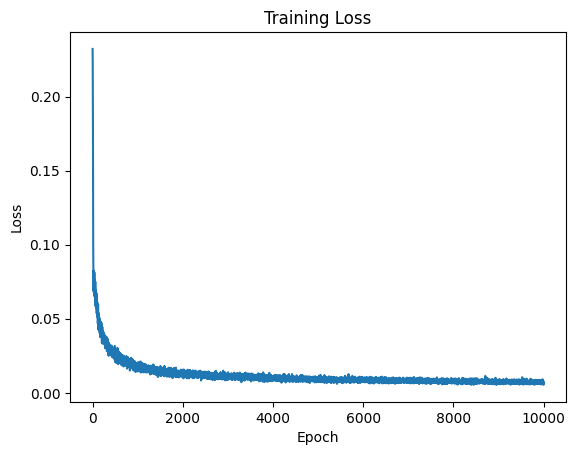

In [13]:
plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.show()

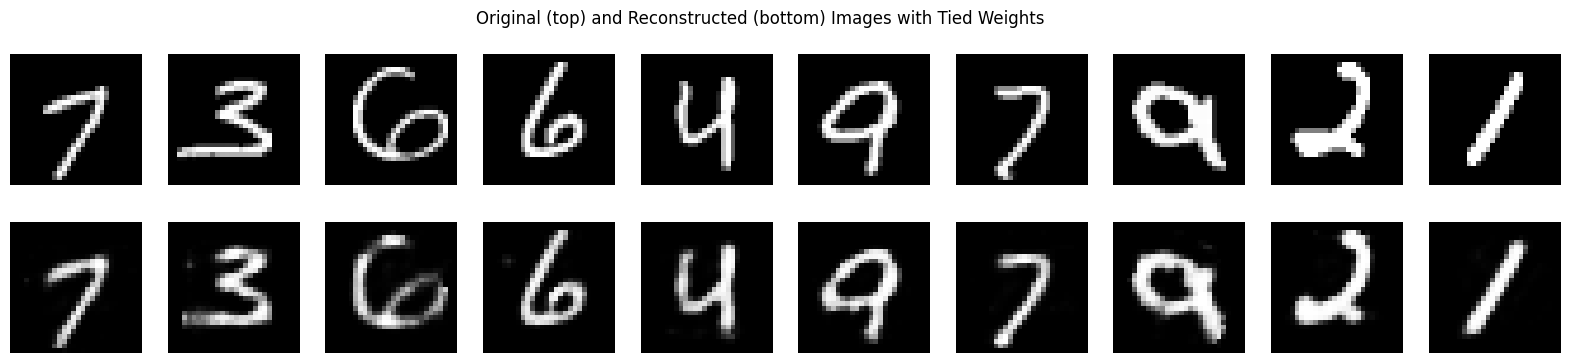

In [15]:
# visualization of original and reconstructed images
model.eval()
with torch.no_grad():
    # select a random batch of images
    randomidx = np.random.choice(X.shape[0], size=10, replace=False) # random minibatch of 10 images
    X_batch = X[randomidx]

    output = model(X_batch)
    output = output.view(-1, 28, 28) # reshape the output to image format

    fig, axes = plt.subplots(2, 10, figsize=(20, 4))
    for i in range(10):
        axes[0, i].imshow(X_batch[i].numpy(), cmap='gray')
        axes[0, i].axis('off')
        axes[1, i].imshow(output[i].numpy(), cmap='gray')
        axes[1, i].axis('off')
    plt.suptitle("Original (top) and Reconstructed (bottom) Images with Tied Weights")
    plt.show()

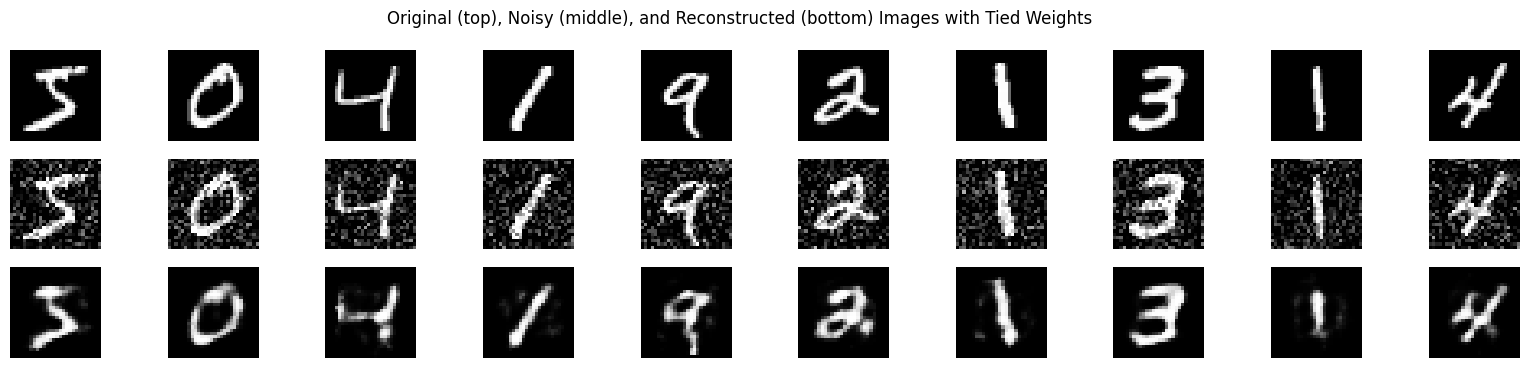

In [20]:
X_noise = X + 0.25 * torch.randn_like(X) # add Gaussian noise to the input images
X_noise = torch.clamp(X_noise, 0., 1.) # clip the noisy

y = model(X_noise)

# plot original, noisy, and reconstructed images
fig, axes = plt.subplots(3, 10, figsize=(20, 4))
model.eval()
with torch.no_grad():
    for i in range(10):
        axes[0, i].imshow(X[i].numpy(), cmap='gray')
        axes[0, i].axis('off')
        axes[1, i].imshow(X_noise[i].numpy(), cmap='gray')
        axes[1, i].axis('off')
        axes[2, i].imshow(y[i].view(28, 28).numpy(), cmap='gray')
        axes[2, i].axis('off')
    plt.suptitle("Original (top), Noisy (middle), and Reconstructed (bottom) Images with Tied Weights")
    plt.show()

Advantages of tied weights: fewer model parameters to train. Lower risk of overfitting and genearlly comparable performance to non-tied wieghts.

Disadvantages: Performance might be lower, no theoretical guarantee that decoding is best done by morring encoding. Tricker to code.